In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")
from diffPLOG2TROE.rate_constants import FallOff
from diffPLOG2TROE.rate_constants import Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

import matplotlib.pyplot as plt
from matplotlib import rcParams

import numpy as np
import seaborn as sns
rcParams["text.usetex"] = True

In [2]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

In [10]:
starting_plog = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03],
        ]
    },
}

param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
}

refitter = PlogRefitter(
    starting_plog,
    T_range=(300, 2500),
    P_range=(0.1, 100),
    n_T=100,
    n_P=100,
    param_config=param_config
)

nlopt_options = {
    "algorithm": "ISRES",  # Global evolutionary optimizer
    "max_eval": 50000,
    "ftol_rel": 1e-6,
    "xtol_rel": 1e-6
}
initial_troe = refitter.fit(nlopt_options=nlopt_options)

optax_options = {
    "algorithm": "adam",
    "learning_rate": 5e-4,
    "max_steps": 100000,
    "ftol": 1e-6,
    "patience": 3000,
    "clip_norm": 1.0,
    "use_scheduler": True,
    "schedule_type": "exponential",
    "decay_rate": 0.95,
    "steps_file": 1000,
}

troe = refitter.fit(loss_type="log", optax_options=optax_options)

print(FallOff(troe))

Plog 2 TROE refitter
 Temperature range [K]: (300, 2500)
 Pressure range [atm]: (0.1, 100)

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value


Starting hybrid optimization
First guess estimate of the parameters:
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 1.213e+27, -4.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 9.800e+02, 2.800e+02, 2.100e+03

  Step 0: loss = 1.341074e+01, grad_norm = 7.163803e+00
  Step 1000: loss = 1.137204e+01, grad_norm = 7.162134e+00
  Step 2000: loss = 7.303046e+00, grad_norm = 7.146315e+00
  Step 3000: loss = 3.257086e

NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW  / 		4.24195e+30 -4.14630 2.87473e+03 /
 TROE / 5.07348e-01 1.01577e+03 2.36263e+02 2.14632e+03 /


0.7693038466044155
1.3326396690838116


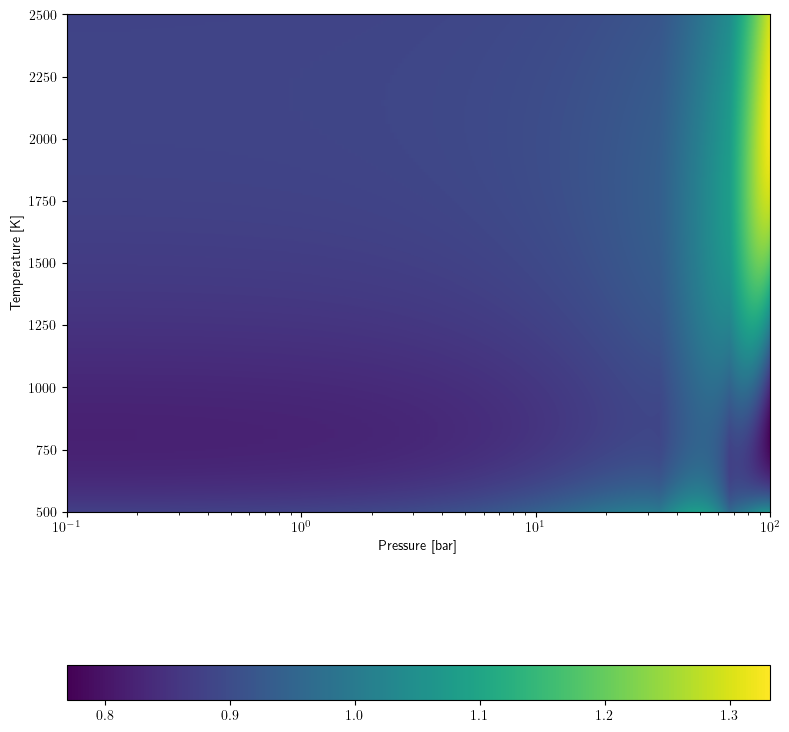

In [11]:
T_range = jnp.linspace(500, 2500, 1000)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 1000)

T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

falloff = FallOff(troe)
plog = Plog(starting_plog)
k_falloff_map = falloff.kinetic_constant(T_range, P_range)
k_plog_map = plog.kinetic_constant(T_range, P_range)
    
ratio = k_falloff_map.T / k_plog_map.T

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin='lower',
    aspect='auto',
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap='viridis'
)
    
plt.xscale('log')
plt.xlabel('Pressure [bar]', fontweight='bold')
plt.ylabel('Temperature [K]', fontweight='bold')
    
cbar = plt.colorbar(im, orientation='horizontal', pad=0.2)
# cbar.set_label(r'$\mathbf{k_{\text{TROE}} / k_{\text{PLOG}}}$')

print(jnp.min(ratio))
print(jnp.max(ratio))

plt.tight_layout()
plt.show()

In [ ]:
2.04845149e+24, -2.81550288e+00,  4.53502327e+03,
3.14791725e+29, -3.78548709e+00,  2.23670630e+03,
2.44457187e-01,  1.68097665e+02,  6.38945433e+29, 1.86787948e+29

In [ ]:
falloff = FallOff(troe)
troe_old = {
    "name": "NH2+H=NH3",
    "type": "falloff",
    "falloff-type": "troe",
    "rate-constant": {
        "hpl-coefficients": [2.04845149e+24, -2.81550288e+00,  4.53502327e+03],
        "lpl-coefficients": [3.14791725e+29, -3.78548709e+00,  2.23670630e+03,],
        "falloff-coefficients": [2.44457187e-01,  1.68097665e+02,  6.38945433e+29, 1.86787948e+29],
    },
}
falloff_old = FallOff(troe_old)
print(falloff_old)

# Get the rate constants
k_plog = refitter.k_plog
k_troe = falloff.kinetic_constant(refitter.T_range, refitter.P_range)
k_troe_old = falloff_old.kinetic_constant(refitter.T_range, refitter.P_range)

# Compute ratio
ratio = k_plog.T / k_troe.T
ratio_old = k_plog.T / k_troe_old.T

print(
    f'Max ratio: {jnp.max(ratio):.2f}\n'
    f'Min ratio: {jnp.min(ratio):.2f}\n'
)
print(
    f'Max ratio: {jnp.max(ratio_old):.2f}\n'
    f'Min ratio: {jnp.min(ratio_old):.2f}\n'
)

In [ ]:
T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 100)
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

plog = Plog(starting_plog)
troe = FallOff(troe_constant)

k_plog = plog.kinetic_constant(T_mesh.flatten(), P_mesh.flatten())
k_troe = troe.kinetic_constant(T_mesh.flatten(), P_mesh.flatten())

ratio = k_troe / k_plog
    
print(f"Maximum ratio: {jnp.max(ratio):.4f}")
print(f"Minimum ratio: {jnp.min(ratio):.4f}")

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin='lower',
    aspect='auto',
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap='viridis'
)    
plt.xscale('log')
plt.xlabel('Pressure [bar]')
plt.ylabel('Temperature [K]')
    
cbar = plt.colorbar(im, orientation='horizontal', pad=0.2)
cbar.set_label("\\textbf{k\\textsubscript{TROE} / k\\textsubscript{PLOG}}")    
plt.tight_layout()
plt.show()

In [ ]:
T_range_map = jnp.linspace(500, 2500, 1000)
P_range_map = jnp.logspace(jnp.log10(P_min), jnp.log10(P_max), 4)
T_mesh, P_mesh = jnp.meshgrid(T_range_map, P_range_map)

for i, t in enumerate(T_mesh):
    k_troe = troe.kinetic_constant(t, P_mesh[i])
    k_plog = plog.kinetic_constant(t, P_mesh[i])
    ratio = k_troe / k_plog
    

# Create plot
num_pressures = len(P_range_map)

plt.figure(figsize=(10, 12))
legend1_lines = []

for i in range(num_pressures):
    color = colors[i]
    line1 = plt.plot(
        T_range_map,
        k_falloff_map[i], 
        label=f'P={float(P_range_map[i]):.2f} atm',
        linestyle='-',
        color=color
    )[0]
    plt.plot(
        T_range_map,
        k_plog_map[i],
        linestyle='--',
        color=color
    )
    legend1_lines.append(line1)

line_falloff = plt.plot([], [], color='black', linestyle='-', label='Falloff')[0]
line_plog = plt.plot([], [], color='black', linestyle='--', label='PLOG')[0]

plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Rate Constant')
plt.title('Comparison of Falloff and PLOG Rates')

plt.gca().set_box_aspect(1)
plt.subplots_adjust(right=0.8)

legend1 = plt.legend(handles=legend1_lines, bbox_to_anchor=(0.72, 1), loc='upper left')
plt.legend(handles=[line_falloff, line_plog], bbox_to_anchor=(0.02, 0.1), loc='upper left')
plt.gca().add_artist(legend1)

plt.grid(True)
plt.show()

In [ ]:
fixed_params = {
    "A_high": 1.5e+14,
    "n_high": 0.167,
    "E_high": .0,
}
refitter = PlogRefitter(starting_plog, T_range=(500, 2500), P_range=(0.1, 100), n_T=300, n_P=300)
refitter.fit(n_steps=5000, steps_file=1000, fixed_params=fixed_params)

In [ ]:
basic_adam_config: Dict[str, Any] = {
    "algorithm": "adam",          # Optimizer algorithm
    "learning_rate": 1e-3,        # Fixed learning rate
    "max_steps": 1000,            # Maximum optimization iterations
    "patience": 50,               # Early stopping patience
    "ftol": 1e-6,                 # Improvement threshold for early stopping
    "clip_norm": 1.0,             # Gradient clipping norm
    "steps_file": 10              # Logging interval
}

# Example 2: Adam with cosine learning rate scheduler
adam_cosine_config: Dict[str, Any] = {
    "algorithm": "adam",
    "learning_rate": 1e-3,        # Will be used as peak_value
    "max_steps": 2000,
    "patience": 100,
    "ftol": 1e-6,
    "clip_norm": 1.0,
    "steps_file": 20,
    
    # Scheduler configuration
    "use_scheduler": True,
    "schedule_type": "cosine",
    "warmup_steps": 200,          # Gradual warmup period
    "decay_steps": 1800,          # Decay period after warmup
    "end_value": 1e-5             # Final learning rate
}

# Example 3: SGD with linear learning rate scheduler
sgd_linear_config: Dict[str, Any] = {
    "algorithm": "sgd",
    "learning_rate": 0.1,         # Higher initial rate for SGD
    "max_steps": 5000,
    "patience": 200,
    "ftol": 1e-5,
    "clip_norm": 2.0,
    "steps_file": 50,
    
    # Linear schedule configuration
    "use_scheduler": True,
    "schedule_type": "linear",
    "decay_steps": 5000,          # Linear decay over all steps
    "end_value": 1e-3             # Final learning rate
}

# Example 4: AdamW with exponential learning rate scheduler
adamw_exp_config: Dict[str, Any] = {
    "algorithm": "adamw",
    "learning_rate": 5e-4,
    "max_steps": 3000,
    "patience": 150,
    "ftol": 1e-6,
    "clip_norm": 1.0,
    "steps_file": 25,
    
    # Exponential schedule configuration
    "use_scheduler": True,
    "schedule_type": "exponential",
    "warmup_steps": 500,          # Gradual warmup
    "decay_steps": 2500,          # Decay period
    "end_value": 5e-6             # Final learning rate
}

# Example 5: Advanced configuration with all options specified
advanced_config: Dict[str, Any] = {
    "algorithm": "adam",
    "learning_rate": 2e-3,        # Base learning rate
    "max_steps": 10000,
    "patience": 300,
    "ftol": 1e-7,
    "clip_norm": 0.5,             # More aggressive gradient clipping
    "steps_file": 100,
    
    # Complete scheduler configuration
    "use_scheduler": True,
    "schedule_type": "cosine",
    "init_value": 1e-6,           # Starting value (during warmup)
    "peak_value": 2e-3,           # Peak value after warmup
    "warmup_steps": 1000,         # Longer warmup (10% of training)
    "decay_steps": 9000,          # Longer decay period
    "end_value": 1e-7             # Very small final learning rate
}